https://claude.ai/chat/5b7e58c0-cd60-45b7-9a02-e657beebe6c1

---

   This is the shift-and-add multiplication algorithm -- it's essentially how
   you do long multiplication by hand in binary, but automated in hardware.
   

---
   ... 


MULTIPLY: shift and add
   Multiplication by conditional shift and add -- the same long multiplication
   you do by hand, but one bit at a time


THE ALGORITHM (repeat for each bit of `mp`)
   1. Test LSB of `mp`
      If LSB = 1 -> add `mc` to `pr` (product). If LSB = 0 -> do nothing.
   2. Shift `mc` left
      Doubles mc, aligning it with the next bit position.
   3. Shift `mp` right
      Drops the tested `LSB`, exposing the next bit.

---
      Multiplier (mp)   -- 4 bits, shift right -->
      Multiplicand (mc) -- 8 bits, shift left  <--
      Product (pr)      -- 8 bits, accumulates additions


BINARY LONG MULTIPLICATION (like decimal, but simpler!)
   For each bit of `mp` (from LSB to MSB): if the bit is 1, add a shifted copy 
   of `mc`. If 0, skip. This is exactly what the hardware does -- but one step
   at a time using shift registers.      



HARDWARE ARCHITECTURE (first version)
   Multiplicand (`mc`)
      `128-bit regiser`
      Starts in right half. Shifts LEFT each step, doubling its value to align
      with each bit position.
   Multiplier (`mp`)
      `64-bit register`
      Shifts RIGHT each step. The LSB is tested by the control unit to decide
      whether to add.
   Product (`pr`)
      `128-bit register`
      Accumulates partial products. When `mp`'s LSB = 1, the ALU adds `mc` to
      `pr`.
   Control 
      `Finite state machine`
      Tests LSB (`mp`), triggers conditional add, then signals both shifts. 
      Repeats 64 times for RISC-V.


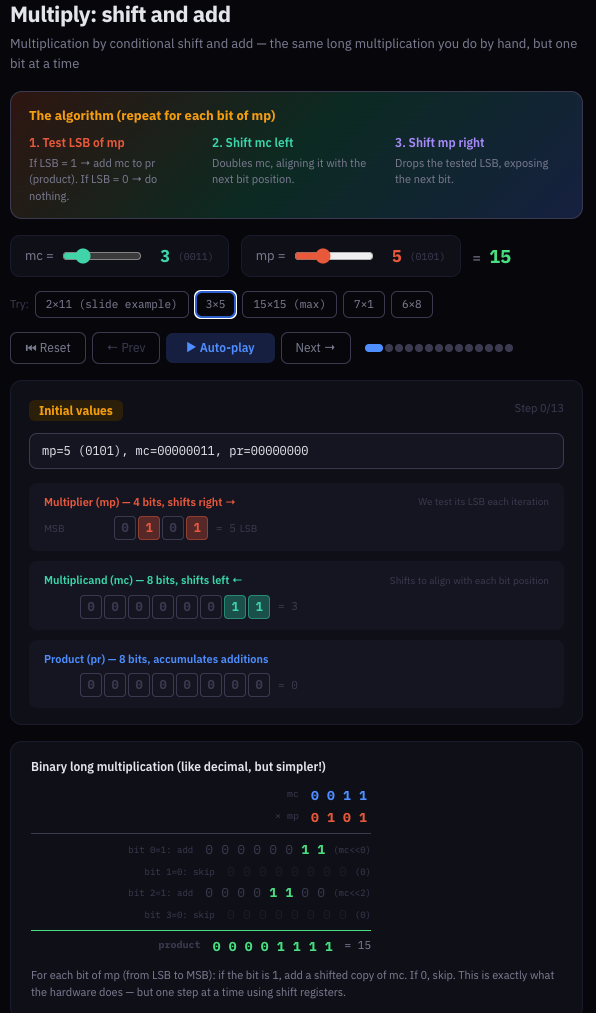

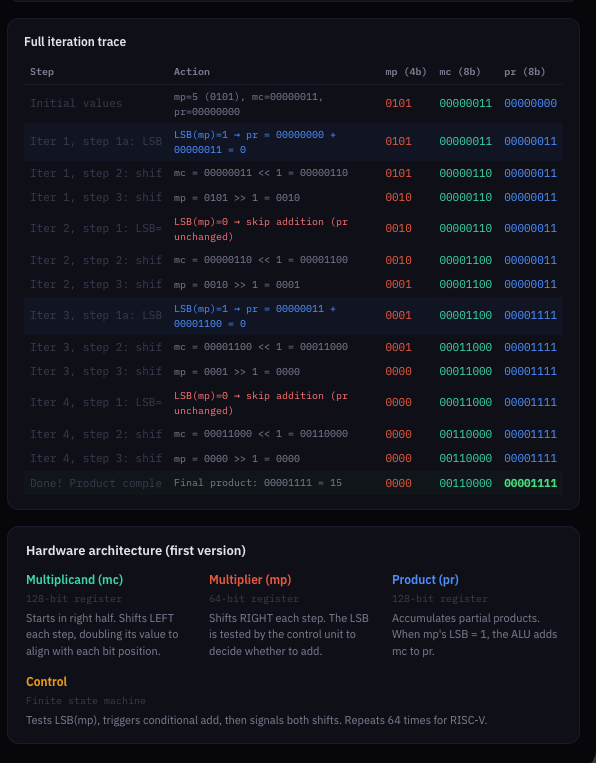

   these slides show a beautiful hardware optimisation journey -- three versions
   of the multiplier, each eliminating hardware by noticing redundancies. ...


---
   ...

   VERSION 1 -- The naive version you already know. `mc` is 8 bits wide and 
   shifts LEFT each iteration. The ALU needs to be 128 bits wide (wasteful!).
   Watch how `mc` grows: 0000 0010 --> 0000 0100 -> ... -> 0001 0000. Most of
   those bits are zeros -- wasted silicon.

   VERSION 2 -- The clever flip. `mc` stays fixed at 4 bits (0010). Instead of 
   `mc` moving let, `pr` SHIFTS RIGHT. The effect is identical: the relative
   position between `mc` and the product changes by one bit each step. But now
   the ALU only needs to add in the upper 4 bits of `pr`, so it shrinks to 64
   bits. Watch the `pr` register: after adding `mc` to the left half, the whole
   thing shifts right, and the product bits "fall into place" in the lower half.

   VERSION 3 -- The final trick. Notice how `pr` starts as `0000 0011` -- that's
   `mp` (0011) loaded directly into `pr`'s right half! There's no separate `mp`
   register at all. Each iteration, the LSB of `pr` is the multiplier bit being
   tested. After the shift right, that bit drops off and the next one appears.
   The `mp` bits naturally get confusmed as the product bits fill in from the 
   left. Watchh it closely: the right half starts as `0011` (mp=3), and by the
   end it's `0110` (product = 6).

   TRY 15x15 to see all three crucnhing through the maximum case -- every bit is
   1, so every iteration adds. The three arrive at the same answer (225) but V3
   does it with one fewer register.

   The comparison table at the bottom puts the savings in perspective: for a 
   64-bit RISC-V processor, V3 saves 192 bits of register storage compared to V1    
   -- that's 43% less hardware for the same computation. The green checkmark 
   ...



- 64-bit ALU
- 64-bit mc (fixed)
- No `mp` register!
- 128-bit `pr` (`mp` inside)


---
   

   V1 --> V2 INSIGHT: Shifting `mc` left by 1 each step is equivalent to 
   shifting `pr` rught by 1 -- either way, `mc`'s value aligns with a higher bit
   position relative to the accumulating product. But shifting `pr` instead 
   means `mc` never changes, so the ALU only needs to add in the upper half or
   `pr`. The `ALU` and `mc` register shrink from 128 bits to 64 bits!

   V2 --> V3 INSIGHT: In V2, both `mp` and `pr` shift right every iteration. The
   bits shifting out of mp's `LSB` are "used up" -- and the bits shifting into
   `pr`'s right half from the left are the new product bits. These two streams
   never collide! So put `mp` in `pr`'s right half at init. As `pr` shifts right
   , the `mp` bits naturally appear at the `LSB` position to be tested, then get
   pushed out as the product fills in from the left. One fewer register, zero
   wasted bits.

   ... the key insight is to REPLACE SUCCESSIVE ADDITIONS WHEN ENCOUNTERING A
   STRING OF ONES BY ONE ADDITION AND ONE SUBTRACTION. This insight is based on
   the property of a GEOMETRIC SERIES -- see next slide... 


   Booth's algorithm exploits the property of a geometric series, which enables
   replacing `k` additions by one subtraction and one addition. The proof is
   simple. There are, however, four cases that need to be considered in the 
   Booth's algorithm...


---
COMPARING THE THIRD ALGORITHM AND BOOTH'S ALGORITHM FOR POSITVE NUMBERS
   ... While the third multiplication algorithm considers only one bit at a time
   , the Booth algorithm considers two bits at a time. The two bits cover the
   four cases: 00, 01, 10, 11. For simple examples like this one, the Booth's
   algorithm does not show any benefit. 

   Division is the trickiest one -- it's "restoring" because if the subtraction
   goes negative, you undo it by adding the divisor back. ...


---
   ...

   THE RESTORING MECHANISM IS THE KEY THING TO SEE. The divisor starts big 
   (0010 0000 = 32) and shifts right each iteration. In the early iterations,
   `ds` (divisor) is way too big for the remainder (7), so every subtraction
   goes negative (the remainder flashes red). The algorithm restores by adding
   `ds` back -- the remainder returns to its previous value, and a 0 goes into
   the quotient.

   Watch the progress dots at the top -- green dots are "accept" steps (`ds` fit
   ), red dots are "restore" steps (`ds` too big). For 7/2, the first three 
   iterations are all restores, then the last two are accepts, building up the
   quotient 00011 = 3.


TRY THESE TO BUILD INTUITION:
   
   15 / 3 (EXACT) -- quotient = 5, remainder = 0. A clean division. Notice the 
   mix of accepts and restores as the algorithm probes whether the divisor fits
   at each bit position. 

   1 / 7 (`ds` > `dd`) -- the divisor is bigger than the dividend, so the 
   quotient should be 0 with remainder 1. Every single iteration restores -- 
   `ds` never fits. The quotient stays all zeros. This shows how the algorithm
   naturally handles this edge case.

   13 / 5 -- quotient = 2, remainder = 3. A nice case where you get a mix of
   restores and accepts, and you can see the remainder shrinking as the 
   algorithm peels off pieces of the dividend. 

   15 / 1 -- quotient = 15, remainder = 0. Every iteration accepts because 1 
   always fits! The quotient fills up with all 1s = 1111 = 15.

   The comparison at the bottom highlights the key differences from 
   multiplication: multiply works LSB -> MSB and conditionally adds (never 
   needing to undo). Division works MSB -> LSB and conditionally subtracts --
   but subtraction might overshoot, so you need the restore step to undo it.
   That's why it's called "restoring" division. 

RESTORING DIVISION
   Conditional shift and subtract -- try subtracting the divisor, and if the 
   result goes negative, restore it.


---
The restoring division algorithm (repeat $N + 1$ times)
   1. Try subtract
      `r' = r - ds`. Speculatively subtract the divisor from the remainder. 
   2. Test `r'`
      If `r' >= 0` -> accept! Shift `q` left, set LSB (q) = 1.
      If `r' < 0`  -> RESTORE `r = r' + ds`. Shift `q` left, set `LSB(q) = 0`.
   3. Shift `ds` right
      Halve the divisor to align with the next bit position. 


---
WHY "RESTORING" DIVISION?

   * When `r' >= 0` (`ds` fits)
      The divisor fits into the current remainder. Accept the subtraction, put a
      `1` in the quotient. Like saying "yes, 1 goes into this at least once."
   * When `r' < 0` (`ds` too big) -- RESTORE
      We overshoot -- the divisor is too big for the current remainder. UNDO by
      adding `ds` back (`r = r' + ds`). Put a `0` in the quotient. Like saying,
      "no, 1 doesn't go into this."


---
vs. MULTIPLICATION:
   Multiply works LSB -> MSB, shifts left and conditionally adds. Division works
   MSB -> LSB, shifts right, and conditionally subtracts. The "restoring" step
   is the key difference -- multiplication never needs to undo, but division 
   might subtract too much and must restore.


---
HARDWARE ARCHITECTURE (first version)

   - DIVISOR (`ds`)
     `128-bit register`
     Starts in left half. Shifts RIGHT each step, aligning with smaller bit
     positions.
   - REMAINDER (`r`)
     `128-bit register`
     Initialised with dividend. ALU subtracts `ds` from `r`; if result negative,
     restores.
   - QUOTIENT (`q`)
     `64-bit register`
     Shifts LEFT each step. New LSB = 1 if `ds` fits, 0 if not (restoring).
   - CONTROL
     `FSM`
     Tries `r - ds`, checks sign. If negative --> restore + q <-- 0. If positive
     --> accept + q <-- 1. Shifts `ds`. Repeat 65x.      

---

-- A Finite-State Machine (FSM) in computer architecture is a mathematical model
   of computation used to design sequential logic circuits and control systems.
   It defines a system that exists in exactly ONE OF A FINITE NUMBER OF STATES
   at any given time, changing from one state to another (a transition) in 
   response to inputs. 

   CORE CONCEPTS OF AN FSM
      An FSM is defined by a 5-tupe structure:

      1. STATES: A finite, fixed set of distinct modes or conditions
         (e.g., Idle, Reading, Writing).
      2. INPUTS: External signals or events that trigger transitions.
      3. TRANSITIONS: Rules that determine the next state based on the current
         state and input.
      4. INITIAL STATE: The starting mode of the system.
      5. OUTPUTS: The result produced by the machine, which may depend on the
         state and/or input.


   TYPES OF FSMs
      * DETERMINISTIC FINITE AUTOMATON (DFA): For every state and input, there 
        is exactly one transition to a next state.
      * NON-DETERMINISTIC FINITE AUTOMATON (NFA): An input can lead to one, more
        than one, or no transition for a given state.
      * MOORE MACHINE: The outputs depend ONLY ON THE CURREMNT STATE. 
      * MEALY MACHNE: The outputs depend on BOTH THE CURRENT STATE AND CURRENT
        INPUT. 


    FSM HARDWARE IMPLEMENTATION    
       In hardware, FSMs are implemented using sequential logic circuits, which
       consist of:
          * State Register (Memory): Flip-flops that store the current state
            variables.
          * Next-State Logic: Combinational logic that determines the next state
            based on inputs and the current state.
          * Output Logic: Combinational logic that determines the output based
            on the current state (Moore) or state+input (Mealy).


   APPLICATIONS IN COMPUTER ARCHITECTURE
      * CPU Control Unit: Manages the fetch-decode-execute cycle.
      * Pattern Recognisers: Detects specific sequences of data, such as in lexical
        analysis for compilers.
      * Bus Controllers: Manages access to system buses.
      * Counters and Timers: Sequential circuits that count in a specific sequence.

   
   ADVANTAGES && DISADVANTAGES
      * ADVANTAGES: Provide a simple, predictabvle, and systematic way to model
        sequential behavior, easily mapping to hardware with minimal resources.
      * DISADVANTAGES: Can become complex ("state explosion") when designing
        large, intricate systems, making them harder to manage without 
        modularity.   

       


#### Finishing...

- refining division implementation
   - remainder shift left: `reduce divisor / ALU size`
   - combine quotient and remainder registers

- RISC-V division instructions
   - `div`: divide
   - `divu`: unsigned divide
   - `rern`: remainder
   - `Remu`: remainder unsigned

- exercise: signed numbers for 
   - multiplication
   - division

- find out more
   * a multipler without carry propagation?
   * can AI help with optimising multipliers?


---
   Just like the first version of the multiplication algorithm which can be
   optimised twice, similar optimisations can be applied to the division
   algorithm -- details can be found ...

   If you are fascinated by how processors perform arithmetic, think about how
   these multiplication and division algorithms can be extended to cover signed
   numbers and floating-point arithmetic. If you are really passionate about
   arithmetic, some interesting...


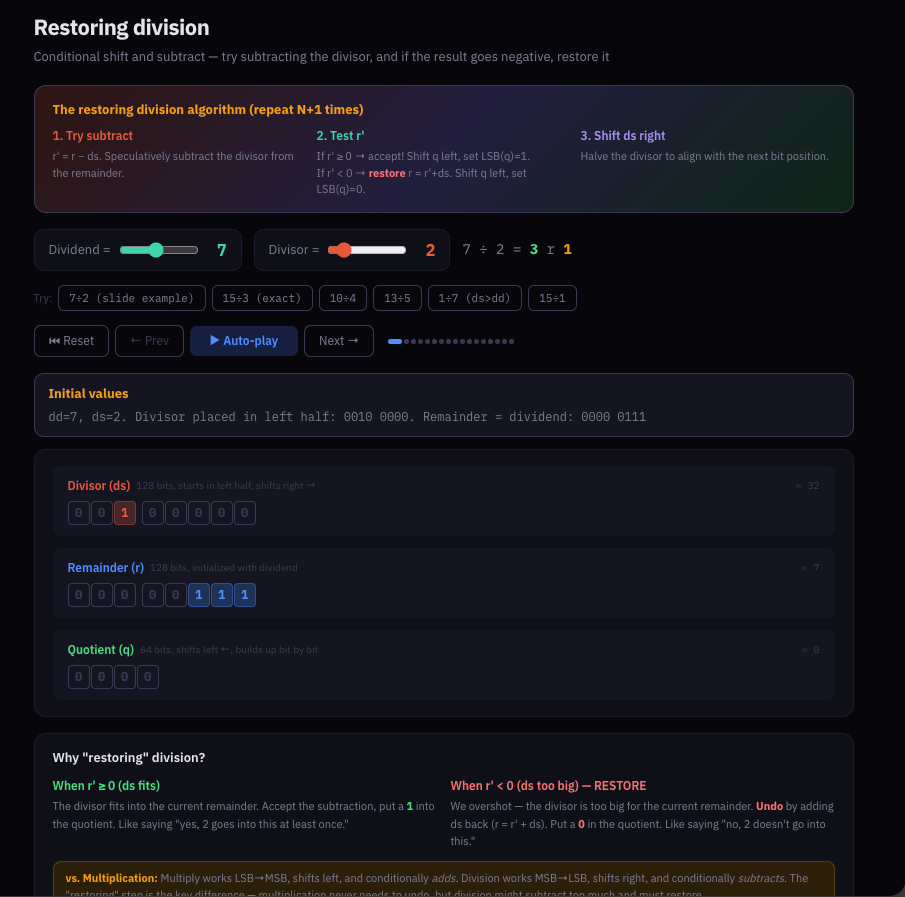

---

   Even the x86 chips in laptops and servers internally translate their complex
   instructions into RISC-like micro-operations. So by learning how a RISC-V 
   datapath works, you're understanding the foundation of essentially every
   processor in existence -- from the chip in your phone to the ones in data
   centres. The "PostPC era" slide highlights that x86 peaked around 2011 for
   PCs and only accounts for roughly 10 million cloud servers, while ARM/RISC
   ships over 20 billion units per year. ... current state of the industry.


STEP 1: BUILD SEPARATE, SIMPLE DATAPATHS FOR EACH INSTRUCTION TYPE.
   You design one datapath that only handles R-type instructions (like 
   `add x9, x20, x21`), another that only handles I-type instructions (like
   `addi x15, x1, -50`), and another for branch instructions (like `beq`). Each
   of these is dead simple because it only needs to do one thing. It's like
   designing three separate single-purpose machines.


STEP 2: MERGE THEM INTO COMBINED DATAPATH USING MUXes.
   When you compare the R-type and I-type datapaths side by side, they're almost
   identical -- the only difference is where the ALU's second input comes from
   (a register vs. an immediate). So you add a MUX that can select between the
   two sources, and now one datapath handles both. You keep repeating this
   merging process, adding MUXes each time you encounter a difference between
   instruction types, until you have one universal datapath that can handle
   everything.


STEP 3: ADD A CONTROL UNIT TO DRIVE THE MUXes. 
   The combined datapath can do everything, but it needs to be told which mode 
   to operate in for each instruction. The Control Unit reads the opcode from
   the current instruction and sets all the MUX select signals, ALU operation,
   and memory read/write signals accordingly. When it sees an R-type opcode, it
   configures the MUXes to behave like the R-type datapath from Step 1. When it 
   sees a Load opcode, it reconfigures everything to behave like tghe Load
   datapath. Same hardware, different configuration each cycle.

   The beauty of this approach is that you never need to understand the full
   combined datapath all at once. You just need to understand each simple 
   datapath individually, then see how MUXes bridge the differences, then see 
   how MUXes bridge the differences, then see how the control unit picks the
   right configuration. ... three layers of understanding, each onee manageable.

---

   ...

HOW TO USE THE ARTIFACT
   
   ... The diagram shows the ENTIRE COMBINED DATAPATH -- but only the components
   releavent to the current instruction light up in colour. Everything else dims
   out. This is ... with the green/red highlighting, except you can toggle 
   between them instantly.

   The two panels below the diagram show you the CONTROL SIGNALS (the 8 outputs
   from the Control Unit) and the DATA FLOW TRACE (the step-by-step journey of
   data through the circuit).


WALK-THROUGH BY INSTRUCTION TYPE

R-type: `add x9, x20, x21`
   Start here -- this is the simplest path. The instruction says "add register
   20 and register 21, store the result in register 9." Watch the data flow:

   The Registers block reads `x20` (value 35) on port A and `x21` (value 7) on
   port B. Both go straight to the `ALU`. The `ALUSrc MUX` is set to `0` --
   meaning "pass through the register value" (not an immediate). The ALU
   computes 35 + 7 = 42. The result bypasses Data Memory entirely (`MemRead=0`,
   `MemWrite=0`), and the `MemToReg MUX` is set to 0 -- meaning "take the `ALU`
   result, not memory data"

   Notice how short the active path is. No memory involved at all.


R-type: `sub x9, x20, x21`
   Identical path -- the only difference is the ALU control changes from `add` 
   to `sub`. The ALU computes `35 - 7 = 28`. Same `MUX` settings, same 
   write-back path. This is why R-type instructions are so clean: the control
   signals are nearly identical, only the ALU operation changes (determined by
   `funct3` and `funct7` fields).


I-type: `addi x15, x1, -50`
   Now click this one and compare to `add`. The path looks almost identical, 
   except for ONE CRITICAL DIFFERENCE: the `ALUSrc MUX` flips to 1. Instead of
   reading a second register, the ALU's B input now comes from the `Imm Gen`
   block, which sign-extends the 12-bit immediate (-50) to 64 bits.

   Ths is exactly slide 7's comparison -- the R-type and I-type datapaths differ
   only at this one MUX. That's why Step 2 of the derivation works: you add one
   `MUX` and suddenly the same hardware handles both instruction types.

   The ALU computes `reg[1] + (-50) = 100 + (-50) = 50`, which writes back to 
   `reg[x15]`.


LOAD: `ld x5, 40(x1)`
   This is where things get more interesting. The path is similar to `addi`
   (`ALUSrc = 1`, using an immediate), but now the ALU result is used as a 
   MEMORY ADDRESS, not as the final answer.

   The ALU computes `reg[1] + 40 = 100 + 40 = 140`. This address goes into Data
   Memory, which reads the value at address 140 (which is 999 in our simulation)
   . The `MemToReg MUX` now flips to 1 -- meaning "take the memory data, not the
   ALU result." So 999 (from memory) writes back to `reg[x5]`, not 140 
   (the address).

   Look at the control signals: `MemRead = 1` is new. And `MemToReg` switches 
   from 0 to 1. Those two signals are what distinguish a Load from an `addi` --
   the hardware path is otherwise nearly identical. 


STORE: `sd x2, 64(x1)`
   Store is Load's mirror. The ALU computes the address the same way 
   (reg[1] + 64 = 164), but instead of reading from memory, it writes to it. 
   The value from `reg[2]` (42) travels to Data memory's write port.

   Two things are different: `MemWrite = 1` instead of `MemRead`, and 
   `RegWrite = 0` -- store doesn't write back to any register. The write-back
   path goes dark.


BRANCH: `beq x20, x21, 100`
   This is the most visually different path. The ALU does a SUBTRACTION
   (`reg[20] - reg[21] = 35 - 7 = 28`) to check equality. Since the result isn't
   zero, the Zero flag = 0, meaning "not equal" -> branch NOT taken. `PCSrc MUX`
   selects `PC+4 = 1004`.

   The upper part of the diagram lights up here -- the branch target adder 
   computes `PC + 100 = 1100` as the potential target, but the PCSrc MUX ignores
   it because Zero=0.

   Now here's what's powerful: if you mentally changed x20 and x21 to have the
   same value, the Zero flag would flip to 1, the `PCSrc MUX` would select the
   branch tagret (generated by Imm Gen --> <<1 --> Add), and PC would jump to 
   1100 instead of 1004. The same hardware, ust diffeent data.


THE KEY TAKEAWAY
   Every instruction uses the SAME COMBINED DATAPATH. The Control Unit just 
   flips a few MUX select bits and enable signals to reconfigure which parts are
   active. The register file at the bottom highlights which registers are 
   playing each role (`rs1` in blue, `rs2` in coral, `rd` in green) -- watch
   these shift as you switch instructions. 

   ... exactly what your lecture means by "the combined datapath behaves like
   the R-type datapath when dealing with R-type instructions, and like the
   I-type datapath when dealing with I-type nstructions." One piece of silicon,
   many personalities -- all controlled by 8 bits from the Control Unit. 

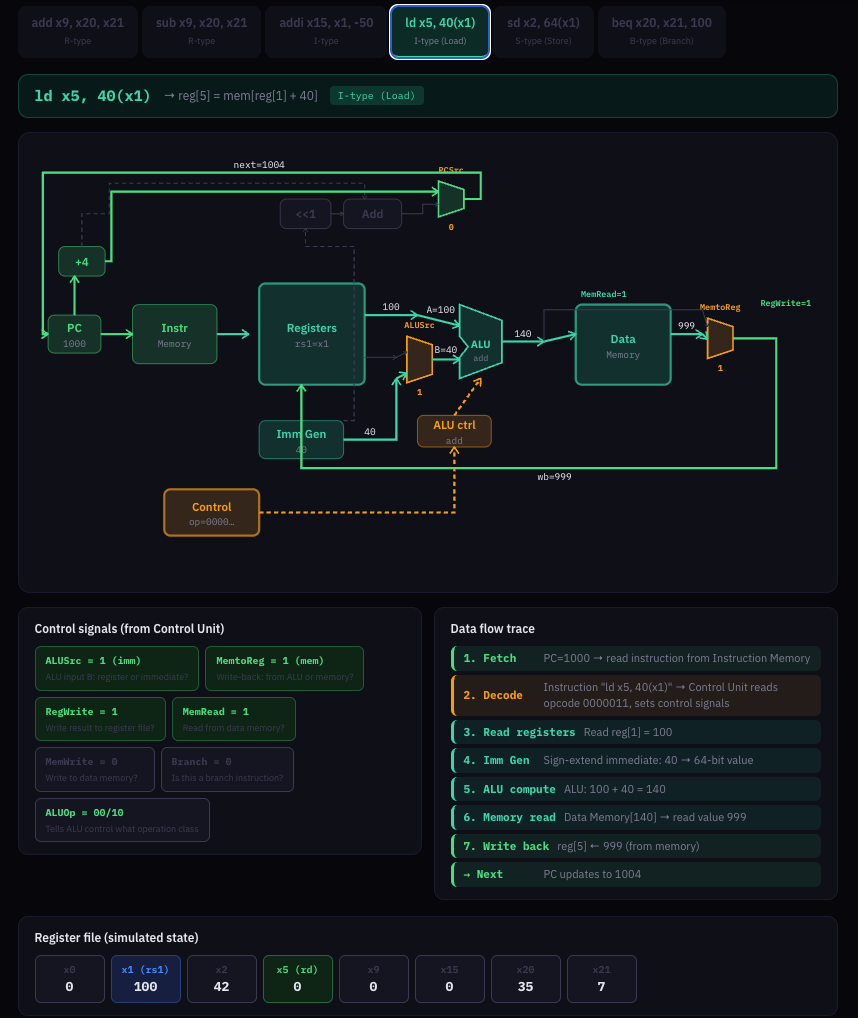

---

   This artifact focuses on the CONTROL UNIT itself -- how it reads the opcode
   and derives all 8 control signals, and how the ALU control block combines
   `ALUOp` with funct fields to pick the exact ALU operation. This is the 
   "brain" that makes the combined datapath work.

   This artifact covers the "brain" of the processor -- the Control Unit and ALU
   control block from pages 15-23. It has three stacked sections that show the
   complete signal derivation chain. ...


HOW TO READ THE THREE SECTIONS
   The flow goes top -> middle -> bottom, mirroring how signals actually 
   propagate in hardware:

-- SECTION 1 (Instruction Encoding) shows the raw 32-bit instruction split into
   fields. The colour coding tells you where each field goes: amber fields
   (opcode) route to the Control Unit, purple fields (funct3/funct7) route to 
   the ALU control block, blue (`rs1`) and coral (`rs2`) go to the register file
   read ports, and green (`rd`) goes to the write port.

-- SECTION 2 (CONTROL UNIT) shows what happens when the opcode arrives. This is
   a pure combinational circuit -- no memory, no state, just a truth table baked
   into logic gates. The 7-bit opcode goes in, and 8 control signals come out
   instantly. The green badges mean "active/on," the red ones mean "off," and
   dim ones are don't cares.

-- SECTION 3 (ALU Control Block) shows the second-level decode. The ALUOp signal
   from the Control Unit tells the ALU control block what class of operation 
   this is. For Load/Store (`ALUOp=00`), it's always "add" -- no need to look at
   `funct` fields. For Branch (`ALUOp=01`), it's always "subtract." Only for
   R-type (`ALUOp=10`) does the ALU control block actually inspect `funct3` and
   `funct7` to determine the exact operation.


---
### WALK-THROUGH BY INSTRUCTION

Start with `add` (R-type)
   The opcode 0110011 enters the Control Unit, which recognises it as R-type and
   outputs: `ALUSrc=0` (use register, not immediate), RegWrite=1 (write the
   result back), MemRead=0, MemWrite=0 (no memory involved), AluOp=10 (meaning
   "check the funct fields").

   Then ALUOp=10 plus funct3=000 and funct7=0000000 enter the ALU control block.
   The truth table highlights the matching row: this combination maps to ALU
   `ctrl = 0010 = add`. Watch the highlighted row in the truth table.


Now click `sub`   
   Almost identical -- same opcode (0110011), same `ALUOp = 10`. The only 
   difference is `funct7` changes from `0000000` to `0100000`. That single bit
   flips the ALU control from `0010` (add) to `0110` (subtract). This is why
   both funct3 and funct7 exist -- they're the fine-grained operation selector
   within R-type instructions.


CLICK `and` THEN `or`
   Same story -- same opcode, same `ALUOp=10`. This time `funct3` changes: 111
   for AND, 110 for OR. The ALU control outputs 0000 (AND) and 0001 (OR)
   respectively. Notice `funct7` is 0000000 for both -- `funct7` is mainly used
   to distinguish add vs sub (where `funct3` is the same for both).


CLICK `ld` (Load)
   Now the opcode changes to 0000011. The Control Unit immediately outputs a
   completely different signal pattern: ALUSrc=1 (use immediate -- the ofset),
   MemRead=1 (read memory), MemtoReg=1 (write memory data back to register),
   RegWrite=1, ALUOp=00.

   Here's the key insight: ALUOp=00 means "just add, don't bother checking 
   `funct` fields." The ALU control blcok doesn't even look at `funct3`/`funct7`
   -- they show as XXX (don't-cares). The ALU always does addition to compute
   the memory address (base + offset). The truth table's first row highlights.


CLICK `sd` (Store)
   Similar to Load but the enable signals flip: `MemWrite=1` instead of MemRead,
   and RegWrite=0 (store doesn't write to a register). `MemToReg` becomes X
   (don't care, since nothing is being written back). ALUOp is still 00 -- still
   just computing an address.


CLICK `beq` (Branch)
   The opcode 1100011 produces yet another pattern: `ALUSrc=0` (compare two
   registers, not an immediate), Branch=1, RegWrite=0, ALUOp=01.

   ALUOp=01 tells the ALU control block "always subtract" -- the ALU computes
   `rs1 - rs2`, and the Zero flag tells the `PCSrc MUX` whether to branch. Again
   , funct fields are don't cares.



---
THE TWO-LEVEL DECODE: WHY IT'S CLEVER
   The summary box at the bottom ties it together for whichever instruction
   you've selected. The reason for splitting control into two blocks (Control 
   Unit + ALU control) rather than one big truth table is efficiency: the 
   Control Unit only needs to look at the 7-bit opcode to derive most signals.
   Only the ALU operation requires the additional funct field inspection -- and
   only for R-type instructions. This keeps the Control Unit's logic small and 
   fast, which matters when it's on the critical timing path of every single 
   clock cycle.

---

### Control Unit + ALU control explorer
   How the opcode becomes control signals, and how funct fields pick the ALU
   operation.


INSTRUCTION ENCODING
   The 32-bit instruction split into fields -- the opcode goes to the Control
   Unit, `funct` fields go to ALU control.


CONTROL UNIT
   A pure combinational circuit: 7-bit opcode in --> 8 control signals out. No
   registers, no state. It's just a truth table in hardware.


ALU CONTROL BLOCK
   Takes 2-bit ALUOp (from Control Unit) + `funct3/funct7` (from instruction)
   -> produces 4-bit ALU control lines. For load/store/branch, ALUOp alone
   determines the operation. For R-type, funct fields are needd too.  

   BRANCH: ALWAYS SUBTRACT. `ALUOp=01` means "subtract to compare." The ALU
   computes rs1 - rs2; if result is zero, the registers are equal. Funct fields
   are don't cares. ALU ctrl is always 0110.


---
Putting it all together for `beq x20, x21, 100`: The opcode 1100011 enters the
Control Unit, which outputs: ALUSrc=0, MemtoReg=X, RegWrite=0, MemRead=0,
MemWrite=0, Branch=1, ALUOp=01 (funct fields don't care) enter the ALU control
block, which outputs ALU ctrl = 0110 ...





---